# Rain shifts

## Imports and files

In [1]:
import os
import re
import pickle
import itertools
from collections import namedtuple
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import geopandas as gpd

import scipy.io as sio
from scipy.interpolate import griddata
from scipy.stats import pearsonr

import contextily as ctx
from shapely.geometry import Polygon, Point

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.lines import Line2D

from swmm_api import read_inp_file, read_out_file, swmm5_run
from swmm_api.input_file import SwmmInput, section_labels as sections


## Functions

In [2]:
def load_outflow_obs_to_df(OBS_outflow_DATA_PATH):
    """ Takes OBSERVATION FILE with outflow data and makes pd Dataframe
    :param output_path: str, path name that have the outflow data
    :return: df_obs_outflow
    """
    df_obs_outflow = pd.read_csv (OBS_outflow_DATA_PATH + ".csv")
    df_obs_outflow.dropna(inplace = True) ; df_obs_outflow.rename(columns={'discharge_cms': 'OBS outflow [CMS]'} , inplace=True, errors='raise')
    df_obs_outflow["date_and_time"] =  pd.to_datetime(df_obs_outflow["date_and_time"], format='%d/%m/%Y %H:%M:%S')
    df_obs_outflow = df_obs_outflow.set_index('date_and_time')
    df_obs_outflow.drop(['Unnamed: 0'], axis=1, inplace=True)

    return df_obs_outflow
    
# df_outflow.to_pickle('df_outflow.pkl')

In [3]:
def data_5min_interpolate(df_to_interpolate):
    """ Takes df column and makes 5 min interpolation
    :param df_to_interpolate: pd, df with index datetime64 type
    :return: df_interpol
    """
    df_interpol = df_to_interpolate.resample('5min').mean()
#     df_interpol= df_interpol.interpolate(method='polynomial', order=3)
    df_interpol= df_interpol.interpolate(method='linear')
    return df_interpol

In [4]:
def load_sim_to_df(sim_output_path):
    """ Takes SWMM FILE with outflow data and makes pd Dataframe
    sim_output_path: str, file name that have the swmm outflow data
    return: sim_df
    """
    sim_df = read_out_file(sim_output_path).to_frame()['system'][''][['outflow', 'rainfall']]
    sim_df.rename(columns={'outflow':'SWMM outflow [CMS]', 'rainfall':'rainfall [mm/h]'}, inplace=True, errors='raise')
    sim_df.index = pd.to_datetime(sim_df.index)
    return sim_df

In [5]:
def observation_and_swmm_hydrograph(storm_df, date):
    """
    This function takes observation and SWMM model outflow and precipitation data and puts it in a hydrograph.
    Params:
     - storm_df: df, The DataFrame that includes the outflow and precipitation data
     - date: date of storm occurrence. Format: 'yyyy_mm_dd'
    Returns: a hydrograph plot for one subcatchment
    """
    
    fig, ax = plt.subplots(figsize=(12, 6))
    fig.suptitle(storm_df.index.strftime('%d/%m/%Y')[0], fontsize=20)

    y_obs_outflow = storm_df['OBS outflow [CMS]']
    y_rainfall = storm_df['rainfall [mm/h]']
    y_sim_outflow = storm_df['SWMM outflow [CMS]']

    ax1 = sns.lineplot(ax=ax, data=y_obs_outflow, color='g', label='Observed outflow')
    ax2 = ax1.twinx()
#     ax2.set_ylabel('Rainfall ($mm/hr$)')

    sns.lineplot(ax=ax2, data=y_rainfall, color='b', label='Rainfall', alpha=0.4)
    ax2.fill_between(storm_df.index, 0, y_rainfall, alpha=0.4, color='b')
#     ax2.set_ylim(ymin=y_rainfall.max() + 50, ymax=0)
    ax2.set_ylim(ymin=70, ymax=0)
    ax1.set_ylim(ymin=0, ymax=90)
    

    sns.lineplot(ax=ax, data=y_sim_outflow, color='r', label='Simulated outflow')

    ax2.set_xlabel('Time', fontsize=18)
    ax2.set_ylabel('Rainfall ($mmhr^{-1}$)', fontsize=18)
    ax1.set_ylabel('outflow ($m^{3}s^{-1}$)', fontsize=18)

    ax2.legend().remove()

    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    handles = handles1 + handles2
    labels = labels1 + labels2
    ax.legend(handles, labels, loc='center right', fontsize=15)

    # set x-axis label format to %d/%m %H
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %H:%M'))
    ax.tick_params(axis='x', labelsize=18, rotation=45)
    ax1.tick_params(axis='y', labelsize=18) ; ax2.tick_params(axis='y', labelsize=18)
    ax1.grid()


    return fig


In [6]:
def stat(storm_df):
    """
    Format statistical data from storm_df DataFrame.
    
    Calculates various statistical parameters based on the storm data in the storm_df DataFrame.
    
    Args:
        storm_df (pandas.DataFrame): DataFrame containing storm data from SWMM and OBS.
        
    Returns:
        Tuple containing the following:
        
        - swmm_total_outflow (float): Total outflow volume in cubic meters calculated from SWMM data.
        - obs_total_outflow (float): Total outflow volume in cubic meters calculated from OBS data.
        - swmm_max_outflow (float): outflow peak in CMS (Cubic Meters per Second) from SWMM data.
        - obs_max_outflow (float): outflow peak in CMS (Cubic Meters per Second) from OBS data.
        - swmm_max_outflow_time (datetime): Time of the outflow peak from SWMM data.
    """
    
    # Total outflow volume [cubic meter]
    swmm_total_outflow = sum(storm_df['SWMM outflow [CMS]'])
    obs_total_outflow = sum(storm_df['OBS outflow [CMS]'])

    # outflow peak [CMS] and time
    swmm_max_outflow = storm_df['SWMM outflow [CMS]'].max()
    swmm_max_outflow_time = storm_df[storm_df['SWMM outflow [CMS]'] == swmm_max_outflow].index[0]

    obs_max_outflow = storm_df['OBS outflow [CMS]'].max()
    obs_max_outflow_time = storm_df[storm_df['OBS outflow [CMS]'] == obs_max_outflow].index[0]
    
    # Total rain
    total_rain = sum(storm_df['rainfall [mm/h]'])*12/60
    return swmm_total_outflow*60*5, obs_total_outflow, swmm_max_outflow, obs_max_outflow, total_rain


In [7]:
def read_rain_shift_txt_file(rain_shift_directory_path, x_shift, y_shift):
    # List all files in the directory
    files_in_directory = os.listdir(rain_shift_directory_path)

    # Filter files with the desired format
    matching_files = [file for file in files_in_directory if "rain_shift_" in file]

    if not matching_files:
        print("No matching files found.")
        return None, None, None

    # Find the file that matches the specified x_shift and y_shift
    x_shift_str = str(abs(x_shift))
    y_shift_str = str(abs(y_shift))
    matching_file = None
    for file in matching_files:
        x_match = re.search(r'x(plus|minus)_(\d+)', file)
        y_match = re.search(r'y(plus|minus)_(\d+)', file)
        
        if x_match and y_match:
            file_x_shift = int(x_match.group(2)) * (1 if x_match.group(1) == 'plus' else -1)
            file_y_shift = int(y_match.group(2)) * (1 if y_match.group(1) == 'plus' else -1)
            if file_x_shift == x_shift and file_y_shift == y_shift:
                matching_file = file
                break

    if not matching_file:
        print(f"No file found with x_shift: {x_shift} and y_shift: {y_shift}")
        return None, None, None

    # Construct the file path
    file_path = os.path.join(rain_shift_directory_path, matching_file)

    # Open and read the contents of the matched file
    with open(file_path, 'r') as file:
        rain_shift_txt = file.read()

    # Return x_shift, y_shift, and file_contents
    return rain_shift_txt

In [8]:
def update_TimeSeriesData(inp, timeseries_text):
    """
    Update the time series data in an input file used for simulation.
    Args:
    - inp (dict): Dictionary containing simulation input data.
    - timeseries_text (str): Text containing transformed time series data.
    Returns:
    - None
    """

    # Update the time series section with new data
    inp[sections.TIMESERIES] = timeseries_text

    # Ensure that the number of time series matches the number of rain gauges
    if len(inp[sections.TIMESERIES].keys()) != len(inp[sections.RAINGAGES].keys()):
        raise ValueError('ERROR: The number of time series does not match the number of rain gauges.')

    # Edit the time series name and its corresponding rain gauge field
    for basin_timeserie in range(len(list(inp[sections.TIMESERIES].keys()))):
        basin_timeserie_name = inp[sections.TIMESERIES][list(inp[sections.TIMESERIES].keys())[basin_timeserie]]['name']
        inp[sections.RAINGAGES][list(inp[sections.RAINGAGES].keys())[basin_timeserie]]['timeseries'] = basin_timeserie_name


In [33]:
def calculate_gradients_and_stats(rain_shift_df, neighbor_distance_threshold=1.5):
    """
    Calculate local gradients, maximum gradient, and domain statistics based on SWMM max outflow values
    and spatial coordinates for both peak and total discharge volume.

    Parameters:
        rain_shift_df (pd.DataFrame): Input DataFrame containing 'West-East Shift (km)', 
                                      'North-South Shift (km)', 'swmm_max_outflow',
                                      and 'swmm_total_outflow' columns.
        neighbor_distance_threshold (float): Maximum distance in km to consider points as neighbors.

    Returns:
        tuple: A tuple containing:
            - Updated DataFrame with new columns 'local_gradient_peak' and 'local_gradient_volume'.
            - A dictionary of rounded domain statistics.
    """
    # Extract coordinates and discharge values
    coords = rain_shift_df[['West-East Shift (km)', 'North-South Shift (km)']].to_numpy()
    peak_flow = rain_shift_df['swmm_max_outflow'].to_numpy()
    volume_flow = rain_shift_df['swmm_total_outflow'].to_numpy()

    # Initialize variables for both peak and total volume gradients
    gradients_peak = []
    gradients_volume = []
    max_gradient_peak = 0
    max_gradient_volume = 0
    point1_peak, point2_peak = None, None  # Store coordinates for peak gradient
    point1_volume, point2_volume = None, None  # Store coordinates for volume gradient

    # Iterate over each point in the domain
    for i, (x_i, y_i) in enumerate(coords):
        local_gradients_peak = []
        local_gradients_volume = []
        for j, (x_j, y_j) in enumerate(coords):
            if i != j:  # Avoid comparing a point to itself
                # Compute Euclidean distance
                distance = np.sqrt((x_i - x_j)**2 + (y_i - y_j)**2)
                
                # Check if the point is a valid neighbor
                if distance <= neighbor_distance_threshold:
                    # Calculate peak discharge gradient
                    gradient_peak = abs(peak_flow[i] - peak_flow[j]) / distance
                    local_gradients_peak.append(gradient_peak)
                    # Update max gradient for peak discharge if a higher value is found
                    if gradient_peak > max_gradient_peak:
                        max_gradient_peak = gradient_peak
                        point1_peak = (x_i, y_i)
                        point2_peak = (x_j, y_j)

                    # Calculate total volume gradient
                    gradient_volume = abs(volume_flow[i] - volume_flow[j]) / distance
                    local_gradients_volume.append(gradient_volume)
                    # Update max gradient for volume if a higher value is found
                    if gradient_volume > max_gradient_volume:
                        max_gradient_volume = gradient_volume
                        point1_volume = (x_i, y_i)
                        point2_volume = (x_j, y_j)

        # Append the max local gradients for the current point
        gradients_peak.append(max(local_gradients_peak) if local_gradients_peak else 0)
        gradients_volume.append(max(local_gradients_volume) if local_gradients_volume else 0)

    # Add local gradients to the DataFrame
    rain_shift_df['local_gradient_peak'] = gradients_peak
    rain_shift_df['local_gradient_volume'] = gradients_volume

    # Calculate average gradients directly from the DataFrame
    average_gradient_peak = rain_shift_df['local_gradient_peak'].mean()
    average_gradient_volume = rain_shift_df['local_gradient_volume'].mean()

    # Calculate additional statistics for peak discharge
    std_dev_peak = rain_shift_df['swmm_max_outflow'].std()
    range_val_peak = rain_shift_df['swmm_max_outflow'].max() - rain_shift_df['swmm_max_outflow'].min()
    cv_peak = (std_dev_peak / rain_shift_df['swmm_max_outflow'].mean()) * 100  # Convert to %

    # Calculate additional statistics for total volume discharge
    std_dev_volume = rain_shift_df['swmm_total_outflow'].std()
    range_val_volume = rain_shift_df['swmm_total_outflow'].max() - rain_shift_df['swmm_total_outflow'].min()
    cv_volume = (std_dev_volume / rain_shift_df['swmm_total_outflow'].mean()) * 100  # Convert to %

    # Prepare and round statistics dictionary
    stats = {
        'max_gradient_peak': max_gradient_peak,
        'max_gradient_volume':max_gradient_volume,
        'gradient_points_peak': (point1_peak, point2_peak),
        'gradient_points_volume': (point1_volume, point2_volume),
        'average_gradient_peak': average_gradient_peak,
        'average_gradient_volume': average_gradient_volume,
        'std_dev_peak': std_dev_peak,
        'std_dev_volume': std_dev_volume,
        'range_val_peak': range_val_peak,
        'range_val_volume': range_val_volume,
        'cv_peak': cv_peak,
        'cv_volume': cv_volume
    }

    return rain_shift_df, stats


## Visualization Functions

In [10]:
def plot_peak_discharge(shift_rain_df, date, filename_date, output_path):
    """
    Improved visualization for peak discharge and rainfall contours with domain statistics.
    """
    
    levels_outflow=np.linspace(0, 50, 21)
    # Define the grid over which you want to interpolate
    grid_x, grid_y = np.mgrid[
        shift_rain_df['West-East Shift (km)'].min():shift_rain_df['West-East Shift (km)'].max():100j,
        shift_rain_df['North-South Shift (km)'].min():shift_rain_df['North-South Shift (km)'].max():100j
    ]

    # Interpolate the swmm_max_outflow and total_rain data
    grid_z_outflow = griddata(
        (shift_rain_df['West-East Shift (km)'], shift_rain_df['North-South Shift (km)']),
        shift_rain_df['swmm_max_outflow'],
        (grid_x, grid_y),
        method='cubic'
    )
    grid_z_rain = griddata(
        (shift_rain_df['West-East Shift (km)'], shift_rain_df['North-South Shift (km)']),
        shift_rain_df['total_rain'],
        (grid_x, grid_y),
        method='cubic'
    )

    # Set the figure size
    plt.figure(figsize=(12, 10))

    # Create the contour plot for swmm_max_outflow
    contour_outflow = plt.contourf(grid_x, grid_y, grid_z_outflow, cmap='viridis', levels=levels_outflow)

    # Add colorbar to show the range of swmm_max_outflow
    cbar_outflow = plt.colorbar(contour_outflow, label='Simulated Max Outflow (m³/s)', pad=0.02)
    cbar_outflow.ax.tick_params(labelsize=14)
    cbar_outflow.set_label('Simulated Max Outflow (m³/s)', fontsize=16)
    
    # Create the contour plot for total_rain in black
    contour_rain = plt.contour(grid_x, grid_y, grid_z_rain, colors='black', levels=10, linewidths=1.5)

    # Add labels for the total_rain contours
    plt.clabel(contour_rain, fmt='%2.1f', colors='black', fontsize=18, inline=True)

    # Reverse date format for the title
    reversed_date = f"{date.split('_')[2]}/{date.split('_')[1]}/{date.split('_')[0]}"

    # Find indices of closest grid points to (0, 0)
    x_idx = np.abs(grid_x[:, 0] - 0).argmin()
    y_idx = np.abs(grid_y[0, :] - 0).argmin()

    # Get current, max, and min peak discharge values
    current_peak_discharge = grid_z_outflow[x_idx, y_idx]
    max_peak_discharge = np.nanmax(grid_z_outflow)
    min_peak_discharge = np.nanmin(grid_z_outflow)

    # Create text box for peak discharge values and stats
    textbox_text = (
        f'Peak discharge (m³/s):\n'
        f'Current: {current_peak_discharge:.2f}\n'
        f'Max: {max_peak_discharge:.2f}\n'
        f'Min: {min_peak_discharge:.2f}\n\n'
        f'Statistics:\n'
        f'Max Gradient: {stats["max_gradient_peak"]:.2f} m³/s per km\n'
        f'Average Gradient: {stats["average_gradient_peak"]:.2f} m³/s per km\n'
        f'Standard Deviation: {stats["std_dev_peak"]:.2f} m³/s\n'
        f'Range: {stats["range_val_peak"]:.2f} m³/s\n'
        f'Coefficient of Variation: {stats["cv_peak"]:.2f}%'
    )
    plt.text(
        1.3, 0.7, textbox_text, transform=plt.gca().transAxes,
        bbox=dict(facecolor='white', alpha=0.9), fontsize=14, verticalalignment='center'
    )

    # Add marker at (0, 0) with label 'Current Location'
    plt.scatter([0], [0], marker='*', color='red', label='Current Location', s=150)

    # Add grid and adjust gridline style
    plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

    # Set labels and title
    plt.xlabel('West-East Shift (km)', fontsize=16)
    plt.ylabel('South-North Shift (km)', fontsize=16)
    plt.title(f'{reversed_date} Peak Discharge Change with Rain Location', fontsize=18)

    # Add legend for total rain contours and current location marker outside the plot
    legend_proxy = [
        Line2D([0], [0], color='black', linewidth=1.5, linestyle='-'),  # Total Rain contour legend
        Line2D([0], [0], marker='*', color='red', linestyle='', markersize=10)  # Current Location marker legend
    ]
    plt.legend(
        legend_proxy,
        ['Basin Rainfall (mm)', 'Current Location'],
        loc='center left',
        bbox_to_anchor=(1.3, 0.9),
        fontsize=14
    )

    # Show plot
    plt.tight_layout()

    # Save the plot
    fig_output_file_name = f'{filename_date}_peak_discharge_map.png'
    plt.savefig(os.path.join(output_path, fig_output_file_name), dpi=300, bbox_inches='tight')
    plt.show()


In [11]:
def plot_discharge_peak_and_total(shift_rain_df, date, filename_date, output_path, output_types, stats):
    """
    Plot comparison of total discharge volume and peak discharge with rainfall contours,
    including a statistics text box for each subplot.

    Parameters:
        shift_rain_df (pd.DataFrame): DataFrame containing 'West-East Shift (km)', 
                                      'North-South Shift (km)', and SWMM results.
        date (str): Date in the format 'yyyy_mm_dd'.
        filename_date (str): Original date format for saving the output file.
        output_path (str): Directory where the output plot will be saved.
        output_types (list): List of output types, e.g., ['total_outflow', 'max_outflow'].
        stats (dict): Dictionary containing statistics for peak discharge and total volume gradients.
    """
    # Define the grid over which you want to interpolate
    grid_x, grid_y = np.mgrid[
        shift_rain_df["West-East Shift (km)"].min():shift_rain_df["West-East Shift (km)"].max():100j,
        shift_rain_df["North-South Shift (km)"].min():shift_rain_df["North-South Shift (km)"].max():100j,
    ]

    # Create a figure with two subplots, reduce horizontal space using gridspec_kw
    fig, axes = plt.subplots(
        1, 2, figsize=(24, 12), sharey=True, gridspec_kw={"wspace": 0.05}
    )

    for ax, output_type, title, stat_key_prefix in zip(
        axes,
        output_types,
        ["Total Discharge Volume", "Peak Discharge"],
        ["volume", "peak"],
    ):
        # Interpolate the selected output type
        grid_z = griddata(
            (shift_rain_df["West-East Shift (km)"], shift_rain_df["North-South Shift (km)"]),
            shift_rain_df[f"swmm_{output_type}"],
            (grid_x, grid_y),
            method="cubic",
        )

        # Set colorbar range and label
        if output_type == "max_outflow":
            levels = np.linspace(0, 50, 21)  # Fixed range for peak discharge
            cbar_label = "Simulated Peak Discharge (m³/s)"  # Units for max_outflow
            unit = "m³/s"
        else:
            min_value = np.nanmin(grid_z)
            max_value = np.nanmax(grid_z)
            levels = np.linspace(min_value, max_value, 21)  # Dynamic range for total outflow
            cbar_label = "Simulated Total Discharge Volume (m³)"  # Units for total_outflow
            unit = "m³"

        # Create the contour plot for the selected output type
        contour = ax.contourf(grid_x, grid_y, grid_z, cmap="viridis", levels=levels)

        # Add colorbar to each subplot
        cbar = fig.colorbar(contour, ax=ax, orientation="vertical", fraction=0.046, pad=0.02)
        cbar.set_label(cbar_label, fontsize=18)  # Add units to the colorbar title
        cbar.ax.tick_params(labelsize=16)

        # Interpolate the total_rain data
        grid_z_rain = griddata(
            (shift_rain_df["West-East Shift (km)"], shift_rain_df["North-South Shift (km)"]),
            shift_rain_df["total_rain"],
            (grid_x, grid_y),
            method="cubic",
        )

        # Create the contour plot for total_rain in black
        contour_rain = ax.contour(grid_x, grid_y, grid_z_rain, colors="black", levels=10, linewidths=1.5)

        # Add labels for the total_rain contours
        ax.clabel(contour_rain, fmt="%2.1f", colors="black", fontsize=14)

        # Add marker at (0, 0) with label 'Current Location'
        ax.scatter([0], [0], marker="*", color="red", label="Current Location", s=150)

        # Add grid
        ax.grid(True)

        # Set labels and title for the subplot
        ax.set_xlabel("West-East Shift (km)", fontsize=18)
        if ax == axes[0]:
            ax.set_ylabel("South-North Shift (km)", fontsize=18)
        ax.set_title(title, fontsize=20)

        # Add a statistics text box
        textbox_text = (
            f"{title} Statistics:\n"
            f"Max Gradient: {stats[f'max_gradient_{stat_key_prefix}']:.2f} m³/s per km\n"
            f"Average Gradient: {stats[f'average_gradient_{stat_key_prefix}']:.2f} m³/s per km\n"
            f"Standard Deviation: {stats[f'std_dev_{stat_key_prefix}']:.2f} {unit}\n"
            f"Range: {stats[f'range_val_{stat_key_prefix}']:.2f} {unit}\n"
            f"Coefficient of Variation: {stats[f'cv_{stat_key_prefix}']:.2f}%"
        )
        ax.text(
            1.05,
            0.5,
            textbox_text,
            transform=ax.transAxes,
            bbox=dict(facecolor="white", alpha=0.9),
            fontsize=14,
            verticalalignment="center",
        )

        # Update tick sizes for both axes
        ax.tick_params(axis="both", which="major", labelsize=16)

    # Add a legend for the rainfall contours and current location
    legend_proxy = [
        Line2D([0], [0], color="black", linewidth=1.5, linestyle="-"),  # Total Rain contour legend
        Line2D([0], [0], marker="*", color="red", linestyle="", markersize=10),  # Current Location marker legend
    ]
    axes[1].legend(legend_proxy, ["Basin Rainfall (mm)", "Current Location"], loc="upper right", fontsize=16)

    # Add a title for the entire figure
    reversed_date = f"{date.split('_')[2]}/{date.split('_')[1]}/{date.split('_')[0]}"
    fig.suptitle(f"{reversed_date} - Sensitivity Analysis of Rain Location", fontsize=24)

    # Adjust layout to tighten spacing
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for the suptitle
    fig_output_file_name = f"{filename_date}_peak_and_total.png"
    plt.savefig(os.path.join(output_path, fig_output_file_name), dpi=300, bbox_inches="tight")
    plt.show()


In [13]:
def plot_gradient_peak_and_total(shift_rain_df, date, filename_date, output_path, stats):
    """
    Plot comparison of spatial gradients for peak discharge and total discharge volume.

    Parameters:
        shift_rain_df (pd.DataFrame): DataFrame containing 'West-East Shift (km)', 
                                      'North-South Shift (km)', 'local_gradient_peak', 
                                      and 'local_gradient_volume' columns.
        date (str): Date in the format 'yyyy_mm_dd'.
        filename_date (str): Original date format for saving the output file.
        output_path (str): Directory where the output plot will be saved.
        stats (dict): Dictionary containing statistics for peak and volume gradients.
    """
    # Define the grid for interpolation
    grid_x, grid_y = np.mgrid[
        shift_rain_df['West-East Shift (km)'].min():shift_rain_df['West-East Shift (km)'].max():100j,
        shift_rain_df['North-South Shift (km)'].min():shift_rain_df['North-South Shift (km)'].max():100j
    ]

    # Create a figure with two subplots, reduce horizontal space using gridspec_kw
    fig, axes = plt.subplots(
        1, 2, figsize=(20, 10), sharey=True,
        gridspec_kw={'wspace': 1}  # Reduce horizontal space between subplots
    )

    for ax, gradient_type, title, stats_prefix, gradient_unit, flow_unit in zip(
        axes,
        ['local_gradient_peak', 'local_gradient_volume'],
        ['Peak Discharge Gradient', 'Total Volume Gradient'],
        ['peak', 'volume'],
        ['m³/s per km', 'm³ per km'],  # Units for gradient
        ['m³/s', 'm³']  # Units for flow (std_dev, range)
    ):
        # Interpolate the selected gradient type
        grid_z = griddata(
            (shift_rain_df['West-East Shift (km)'], shift_rain_df['North-South Shift (km)']),
            shift_rain_df[gradient_type],
            (grid_x, grid_y),
            method='cubic'
        )

        # Create filled contour plot for the gradient type
        contourf = ax.contourf(grid_x, grid_y, grid_z, cmap='plasma', levels=20)
        cbar = fig.colorbar(contourf, ax=ax, orientation='vertical', fraction=0.046, pad=0.02)
        cbar.set_label(f'{title} ({gradient_unit})', fontsize=18)
        cbar.ax.tick_params(labelsize=16)

        # Add labels and title for each subplot
        ax.set_title(title, fontsize=20)
        ax.set_xlabel('West-East Shift (km)', fontsize=18)
        if ax == axes[0]:
            ax.set_ylabel('South-North Shift (km)', fontsize=18)

        # Add statistics text box with proper units
        textbox_text = (
            f'{title} Statistics:\n'
            f'Max Gradient: {stats[f"max_gradient_{stats_prefix}"]:.2f} {gradient_unit}\n'
            f'Average Gradient: {stats[f"average_gradient_{stats_prefix}"]:.2f} {gradient_unit}\n'
            f'Standard Deviation: {stats[f"std_dev_{stats_prefix}"]:.2f} {flow_unit}\n'
            f'Range: {stats[f"range_val_{stats_prefix}"]:.2f} {flow_unit}\n'
            f'Coefficient of Variation: {stats[f"cv_{stats_prefix}"]:.2f}%'
        )
        ax.text(
            1.25, 0.5, textbox_text, transform=ax.transAxes,
            bbox=dict(facecolor='white', alpha=0.9), fontsize=14, verticalalignment='center'
        )

        # Add grid and ensure equal aspect ratio
        ax.grid(True)
        ax.set_aspect('equal', adjustable='box')  # Equal aspect ratio

        # Update tick sizes for both axes
        ax.tick_params(axis='both', which='major', labelsize=16)

    # Add a title for the entire figure
    reversed_date = f"{date.split('_')[2]}/{date.split('_')[1]}/{date.split('_')[0]}"
    fig.suptitle(f'{reversed_date} - Comparison of Spatial Gradients', fontsize=24)

    # Adjust layout to tighten spacing
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for the suptitle
    fig_output_file_name = f'{filename_date}_gradient_peak_and_total.png'
    plt.savefig(os.path.join(output_path, fig_output_file_name), dpi=300, bbox_inches='tight')
    plt.show()


In [ ]:

def plot_discharge_with_equal_aspect(shift_rain_df, date, filename_date, output_path, output_types):
    """
    Create publication-quality contour plots comparing discharge metrics with rainfall distribution.
    """
    # Define font properties
    TITLE_FONT = {'fontsize': 22, 'fontweight': 'bold'}
    LABEL_FONT = {'fontsize': 22}
    TICK_FONT = {'labelsize': 20}
    LEGEND_FONT = {'fontsize': 18}
    SUBPLOT_LABEL_FONT = {'fontsize': 22, 'fontweight': 'bold'}
    
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['axes.linewidth'] = 1.0
    
    # Create interpolation grid
    grid_x, grid_y = np.mgrid[
        shift_rain_df['West-East Shift (km)'].min():shift_rain_df['West-East Shift (km)'].max():100j,
        shift_rain_df['North-South Shift (km)'].min():shift_rain_df['North-South Shift (km)'].max():100j
    ]
    
    # Create figure with minimal subplot spacing using constrained layout
    fig, axes = plt.subplots(1, 2, figsize=(14, 10), sharey=True, constrained_layout=True)
    
    # Ensure Total discharge is on the left and Peak discharge is on the right
    subplot_info = [
        {
            'output_type': output_types[1],  # Total discharge
            'title': 'Total volume',
            'unit': '×10$^3$ m$^3$',
            'levels': np.round(np.linspace(shift_rain_df[f'swmm_{output_types[1]}'].min() / 1000,
                                  shift_rain_df[f'swmm_{output_types[1]}'].max() / 1000, 11) / 5) * 5,
            'cbar_label': 'Simulated total volume [×10$^3$ m$^3$ ]',
            'label': '(b)',
            'ax': axes[1]  # Right plot
        },
        {
            'output_type': output_types[0],  # Peak discharge
            'title': 'Peak discharge',
            'unit': 'm$^3$ s$^-1$',
            'levels': np.linspace(0, 55, 12),
            'cbar_label': 'Simulated peak discharge [m$^3$ s$^{-1}$]',
            'label': '(a)',
            'ax': axes[0]  # Left plot
        }
    ]
    
    for info in subplot_info:
        ax = info['ax']
        
        # Interpolate data
        grid_z = griddata(
            (shift_rain_df['West-East Shift (km)'], shift_rain_df['North-South Shift (km)']),
            shift_rain_df[f'swmm_{info["output_type"]}'],
            (grid_x, grid_y),
            method='cubic'
        )
        
        if info['output_type'] == 'total_outflow':
            grid_z /= 1000  # Convert to thousands of m³

        # Contour plot
        contour = ax.contourf(grid_x, grid_y, grid_z, cmap='viridis', levels=info['levels'], extend='both')
        cbar = fig.colorbar(contour, ax=ax, orientation='vertical', fraction=0.05, pad=0.02)
        cbar.set_label(info['cbar_label'], **LABEL_FONT)
        cbar.ax.tick_params(**TICK_FONT)
        
        # Format colorbar ticks
        cbar.ax.set_yticklabels([f'{int(x):d}' for x in cbar.get_ticks()])
        
        # Interpolate rainfall
        grid_z_rain = griddata(
            (shift_rain_df['West-East Shift (km)'], shift_rain_df['North-South Shift (km)']),
            shift_rain_df['total_rain'],
            (grid_x, grid_y),
            method='cubic'
        )
        
        # Add rainfall contours
        contour_rain = ax.contour(grid_x, grid_y, grid_z_rain, colors='black', levels=8, linewidths=1.5)
        ax.clabel(contour_rain, fmt='%2.0f', colors='black', fontsize=18)
        
        # Add marker for current location
        ax.scatter([0], [0], marker='*', color='red', s=200)
        
        # Configure axes
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.set_aspect('equal', adjustable='box')
        ax.set_xlabel('Easting [km]', **LABEL_FONT)
        if ax == axes[0]:
            ax.set_ylabel('Northing [km]', **LABEL_FONT)
#         ax.set_title(info['title'], **LABEL_FONT)
        
        # Subplot label
        ax.text(-0.15, 1.05, info['label'], transform=ax.transAxes, **SUBPLOT_LABEL_FONT)
        ax.tick_params(axis='both', which='major', **TICK_FONT)
    
    # Legend
    legend_elements = [
        Line2D([0], [0], color='black', linewidth=1.5, label='Basin rainfall [mm]'),
        Line2D([0], [0], marker='*', color='red', label='Current location', markersize=10, linestyle='')
    ]
    axes[0].legend(handles=legend_elements, loc='upper right', frameon=True, **LEGEND_FONT)
    
    # Save and display
    plt.savefig(os.path.join(output_path, f'{filename_date}_publication_quality.png'), dpi=600, bbox_inches='tight', format='png')
    plt.show()

In [40]:
def analyze_rainfall_correlation(shift_rain_df, event_date, fig_output_path):
    """
    Computes Pearson correlation, R², and generates scatter plots for total rainfall vs. runoff metrics.

    Parameters:
    - shift_rain_df (pd.DataFrame): Dataframe containing rainfall and runoff data.
    - event_date (str): Date of the storm event, used for saving figures.
    - fig_output_path (str): Path to save the generated figures.

    Returns:
    - dict: Correlation and R² values for total rainfall vs. runoff parameters.
    """
    # Compute Pearson correlation
    corr_total_outflow, p_total_outflow = pearsonr(shift_rain_df['total_rain'], shift_rain_df['swmm_total_outflow'])
    corr_max_outflow, p_max_outflow = pearsonr(shift_rain_df['total_rain'], shift_rain_df['swmm_max_outflow'])
    
    # Compute R² (square of Pearson correlation)
    r2_total_outflow = corr_total_outflow ** 2
    r2_max_outflow = corr_max_outflow ** 2
    
    # Save correlation and R² results
    correlation_results = {
        "event_date": event_date,
        "corr_total_outflow": corr_total_outflow,
        "p_value_total_outflow": p_total_outflow,
        "r2_total_outflow": r2_total_outflow,
        "corr_max_outflow": corr_max_outflow,
        "p_value_max_outflow": p_max_outflow,
        "r2_max_outflow": r2_max_outflow
    }

    # Create scatter plots
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Scatter plot for total_rain vs swmm_total_outflow
    axes[0].scatter(shift_rain_df['total_rain'], shift_rain_df['swmm_total_outflow'], alpha=0.6)
    axes[0].set_xlabel('Total Rain (mm)')
    axes[0].set_ylabel('SWMM Total Outflow (m³)')
    axes[0].set_title(f'Correlation: {corr_total_outflow:.3f}, R²: {r2_total_outflow:.3f}')
    axes[0].grid(True)

    # Scatter plot for total_rain vs swmm_max_outflow
    axes[1].scatter(shift_rain_df['total_rain'], shift_rain_df['swmm_max_outflow'], alpha=0.6, color='orange')
    axes[1].set_xlabel('Total Rain (mm)')
    axes[1].set_ylabel('SWMM Max Outflow (m³/s)')
    axes[1].set_title(f'Correlation: {corr_max_outflow:.3f}, R²: {r2_max_outflow:.3f}')
    axes[1].grid(True)

    # Save figure
    os.makedirs(fig_output_path, exist_ok=True)
    fig_path = os.path.join(fig_output_path, f"rainfall_correlation_{event_date}.png")
    plt.savefig(fig_path, dpi=300)
#     plt.close()

    print(f"Saved correlation plot for {event_date} at: {fig_path}")
    
    return correlation_results


## Run the model for each spatial shift and each storm
## Do it once!
### Create shift_rain_df by x and y shift range

In [18]:
# # Create shift_rain_df by x and y shift range, do it once!

# # EVENTS_L = ['20120113', '20160108', '20180125', '20191213']
# EVENTS_L = ['20160108'] 

# output_types = ['total_outflow', 'max_outflow']
# fig_output_path = r'D:\Development\RESEARCH\Raanana\figures\Sensitivity Analysis\Rain_Shift'
# # Call the function for each event
# for event_idx, filename_date in enumerate(EVENTS_L):
#     print(filename_date)
#     date = '_'.join([filename_date[:4], filename_date[4:6], filename_date[6:]])
    

#     # Define the ranges for x_shifts and y_shifts
#     # x_shifts = np.arange(-5000, 5500, 500)
#     # y_shifts = np.arange(-10000, 10500, 500)

#     x_shifts = np.arange(-10000, 10500, 500)
#     y_shifts = np.arange(-20000, 20500, 500)

#     # Initialize an empty DataFrame with the required columns
#     shift_rain_df = pd.DataFrame(columns=['x', 'y', 'd', 'swmm_total_outflow', 'swmm_max_outflow', 'total_rain'])

#     # Set up the initial parameters
#     sim_dir = os.path.join(r"D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/", date + '/')
#     INP_FILE = r"Final.inp"
#     output_file_name = 'raanana_rain_shift'

#     OBS_FILE = date 
#     obs_outflow_df = data_5min_interpolate(load_outflow_obs_to_df(os.path.join(sim_dir, OBS_FILE)))

#     # Load the SWMM input file
#     inp = read_inp_file(os.path.join(sim_dir, INP_FILE))

#     # Path to the rain shift text files
#     rainshift_txtfiles_path = os.path.join(r"D:\Development\RESEARCH\Raanana\data\rain_radar\SA_rain_radar_transformation", filename_date, "Rain_shift")

#     # Iterate over all combinations of x_shifts and y_shifts
#     results = []

#     for x_shift in x_shifts:
#         for y_shift in y_shifts:
#             # Calculate the distance using the Pythagorean theorem
#             d = np.sqrt(x_shift**2 + y_shift**2)

#             # Read the rain shift text file for the current shifts
#             rain_shift_txt = read_rain_shift_txt_file(rainshift_txtfiles_path, x_shift, y_shift)

#             # Update the TimeSeriesData in the SWMM input file with the shifted rain data
#             update_TimeSeriesData(inp, rain_shift_txt)

#             # Write the modified input file
#             inp.write_file(os.path.join(sim_dir, output_file_name + '.inp'))

#             # Run the SWMM simulation
#             swmm5_run(os.path.join(sim_dir, output_file_name + '.inp'), progress_size=1)

#             # Load the simulation output
#             OUT_FILE = output_file_name + '.out'
#             sim_df = load_sim_to_df(os.path.join(sim_dir, OUT_FILE))

#             # Combine the observed and simulated data
#             storm_df = pd.concat([obs_outflow_df, sim_df], axis=1)
#             storm_df[storm_df < 0] = 0
#             storm_df = storm_df.fillna(0)

#             # Calculate the output metrics
#             swmm_total_outflow, obs_total_outflow, swmm_max_outflow, obs_max_outflow, total_rain = stat(storm_df)

#             # Append the results to the list
#             results.append({
#                 'x': x_shift,
#                 'y': y_shift,
#                 'd': d,
#                 'swmm_total_outflow': swmm_total_outflow,
#                 'swmm_max_outflow': swmm_max_outflow,
#                 'total_rain': total_rain
#             })

#     # Create the DataFrame from the results list
#     shift_rain_df = pd.DataFrame(results)

#     # Save the DataFrame as a pickle file
#     pickle_file_path = os.path.join(sim_dir, 'rain_shift_pickle.pkl')
#     shift_rain_df.to_pickle(pickle_file_path)

#     # Display or save the resulting DataFrame
#     shift_rain_df

20160108


swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2016_01_08/raanana_rain_shift.inp: …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2016_01_08/raanana_rain_shift.inp: …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2016_01_08/raanana_rain_shift.inp: …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2016_01_08/raanana_rain_shift.inp: …

...

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2016_01_08/raanana_rain_shift.inp: …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2016_01_08/raanana_rain_shift.inp: …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2016_01_08/raanana_rain_shift.inp: …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2016_01_08/raanana_rain_shift.inp: …

swmm5 D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/2016_01_08/raanana_rain_shift.inp: …

# Visualization

Saved correlation plot for 2012_01_13 at: D:\Development\RESEARCH\Raanana\figures\Sensitivity Analysis\Rain_Shift/2012_01_13/rainfall_correlation_2012_01_13.png


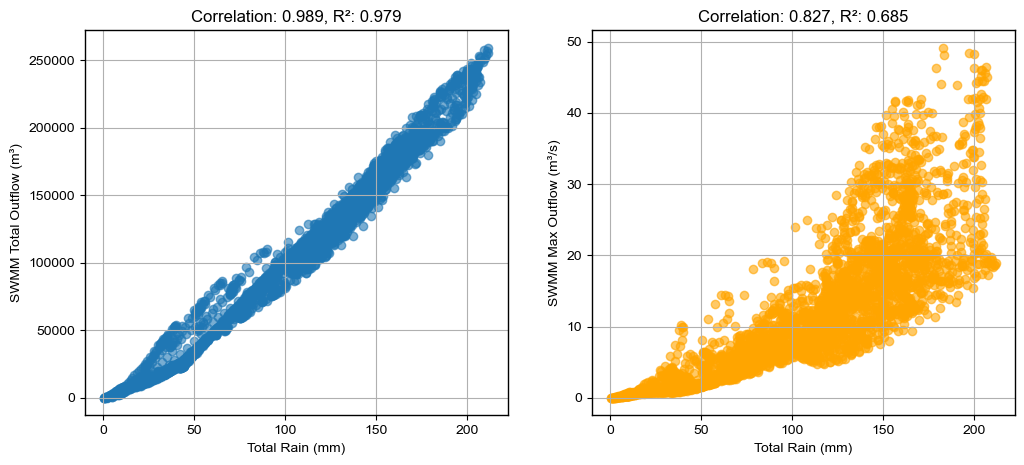

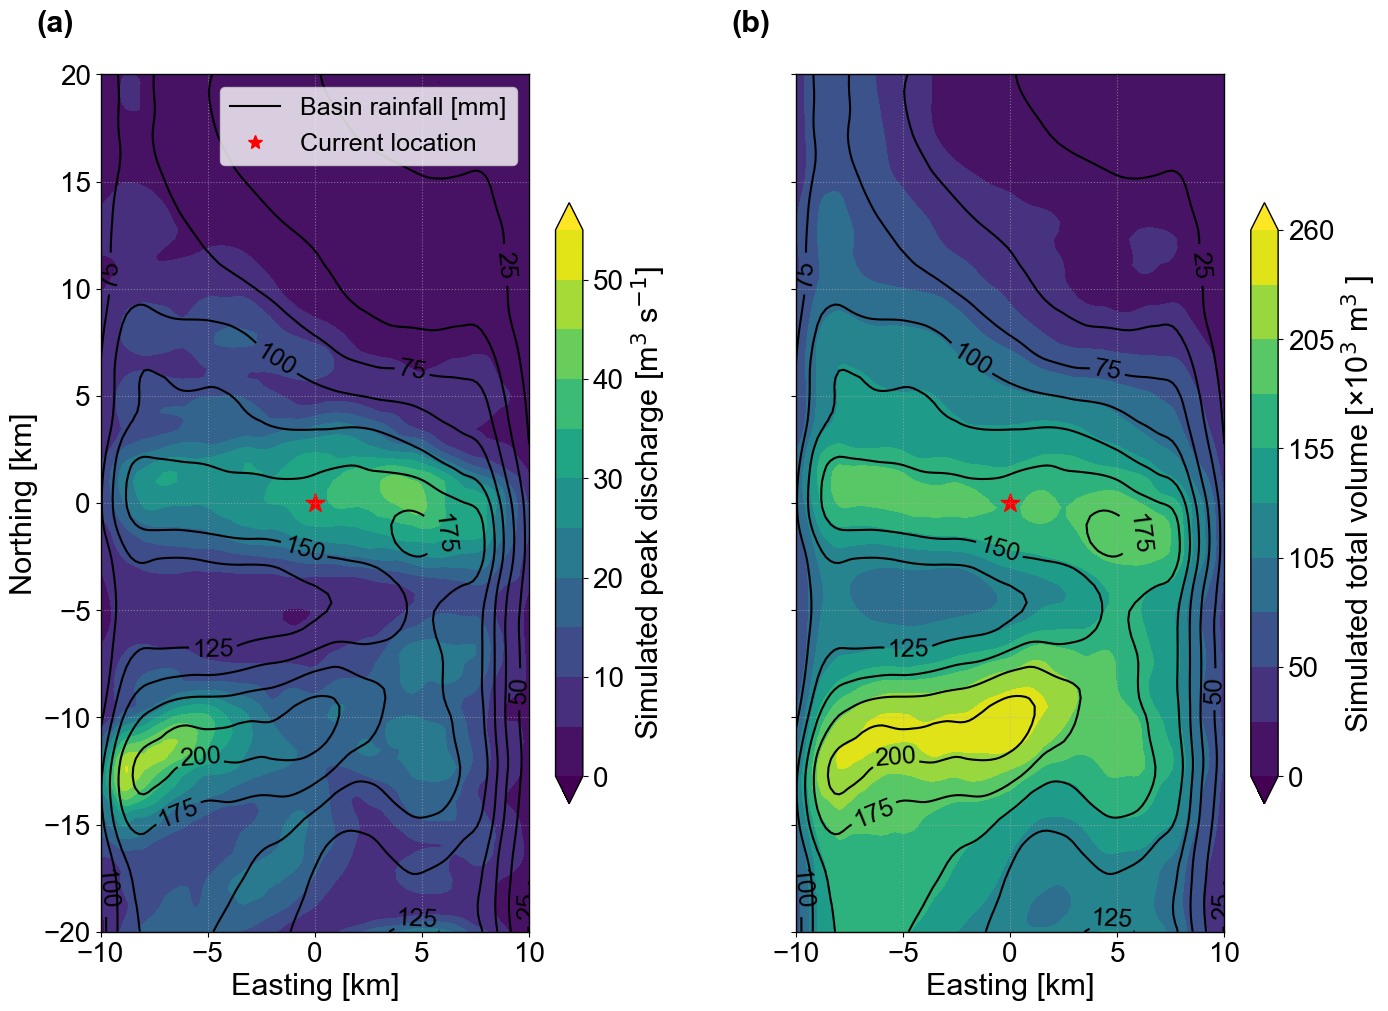

Saved correlation plot for 2016_01_08 at: D:\Development\RESEARCH\Raanana\figures\Sensitivity Analysis\Rain_Shift/2016_01_08/rainfall_correlation_2016_01_08.png


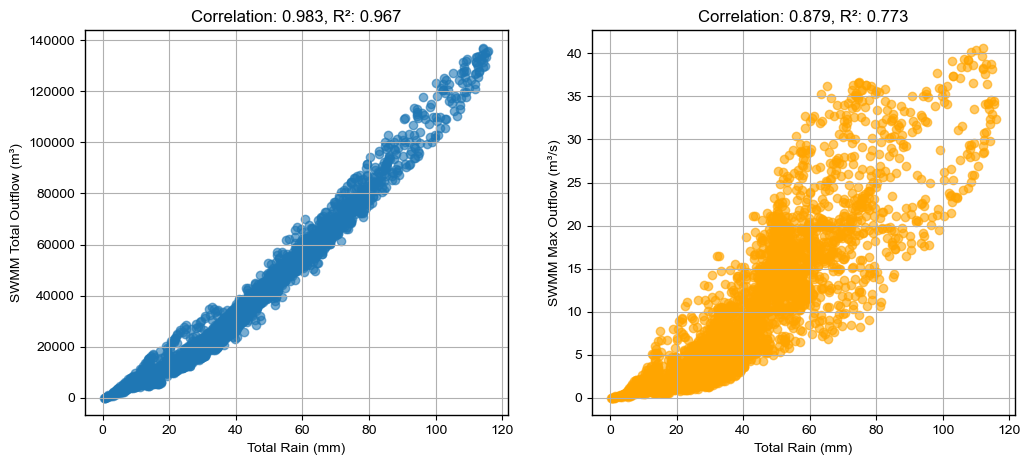

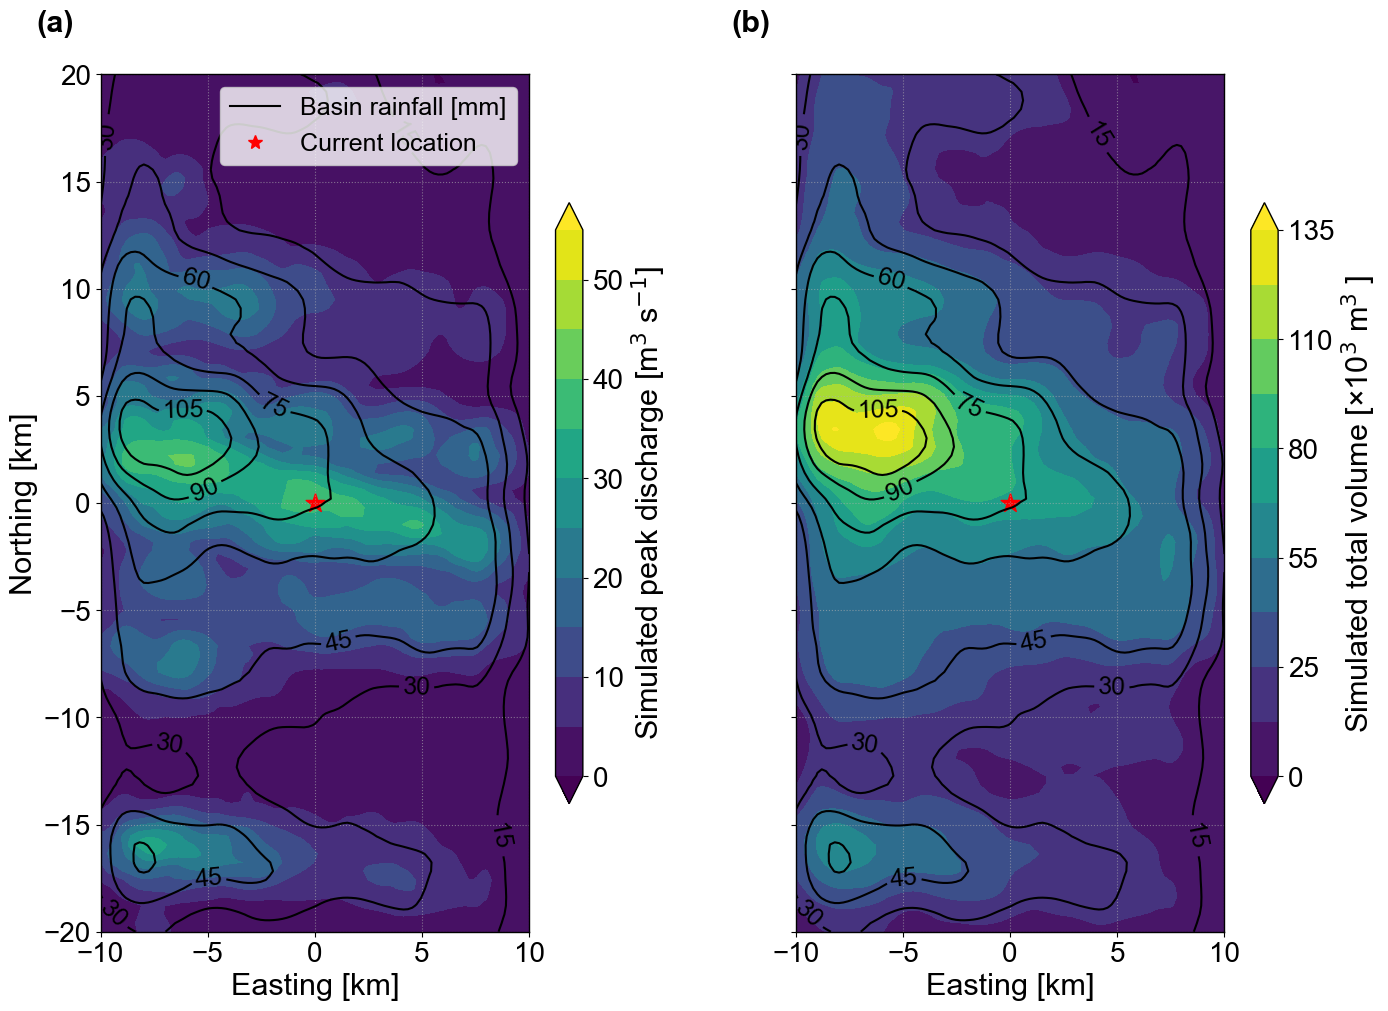

Saved correlation plot for 2018_01_25 at: D:\Development\RESEARCH\Raanana\figures\Sensitivity Analysis\Rain_Shift/2018_01_25/rainfall_correlation_2018_01_25.png


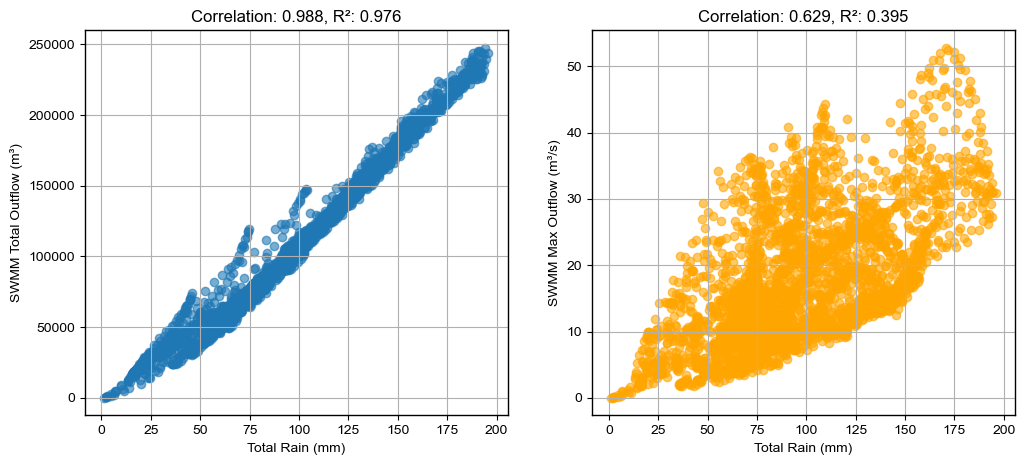

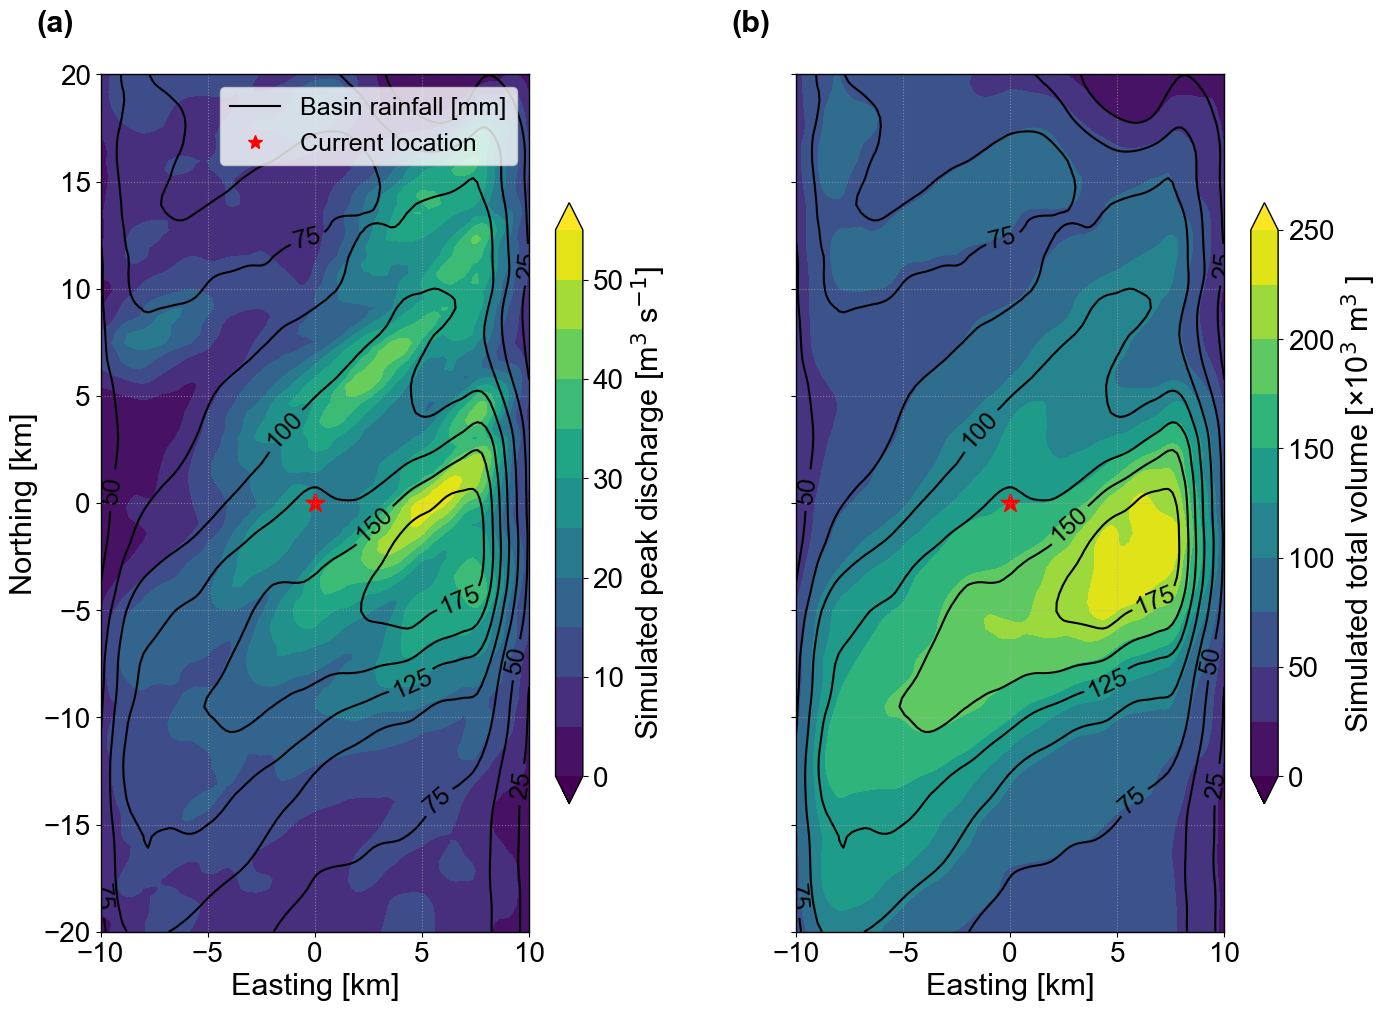

Saved correlation plot for 2019_12_13 at: D:\Development\RESEARCH\Raanana\figures\Sensitivity Analysis\Rain_Shift/2019_12_13/rainfall_correlation_2019_12_13.png


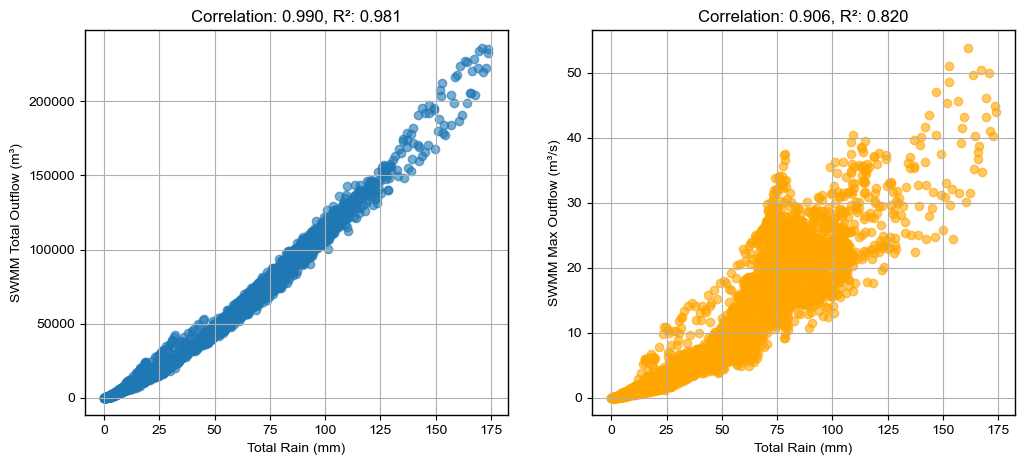

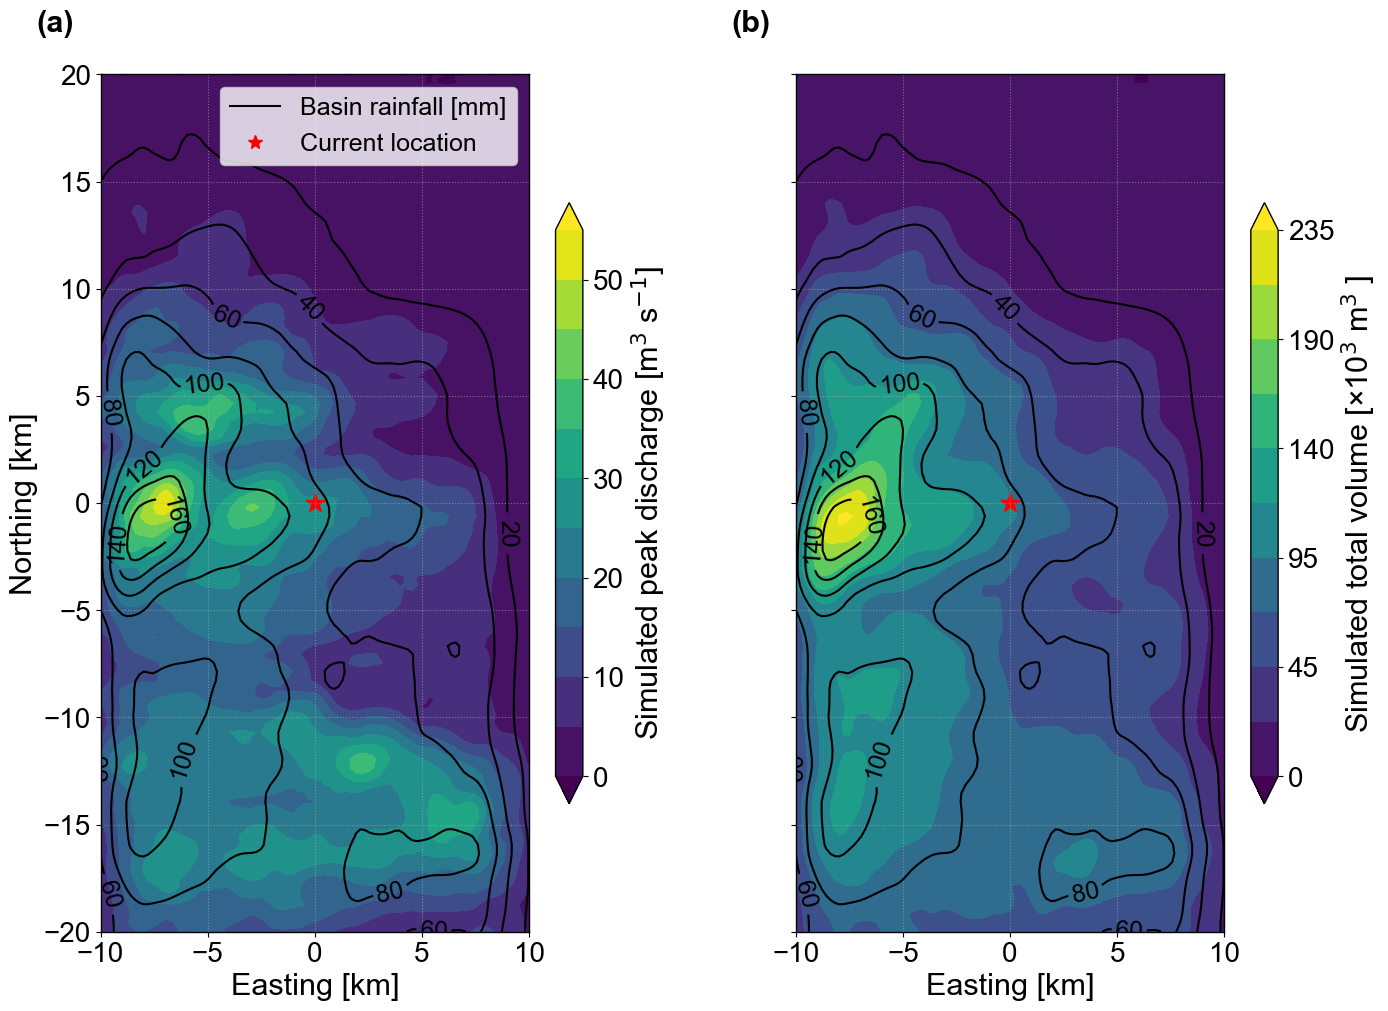

In [48]:
all_event_stats = []
EVENTS_L = ['20120113', '20160108', '20180125', '20191213']
# EVENTS_L = ['20120113', '20180125', '20191213']  # List of events
output_types = ['max_outflow', 'total_outflow']

fig_output_path_base = r'D:\Development\RESEARCH\Raanana\figures\Sensitivity Analysis\Rain_Shift/'

# Loop over each event
for event_idx, filename_date in enumerate(EVENTS_L):
    
    date = '_'.join([filename_date[:4], filename_date[4:6], filename_date[6:]])
    sim_dir = os.path.join(r"D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/", date + '/')
    pickle_file_path = os.path.join(sim_dir, 'rain_shift_pickle.pkl')
    
    # Load the event data
    shift_rain_df = pd.read_pickle(pickle_file_path)

    # Convert x and y axes from meters to kilometers
    shift_rain_df['West-East Shift (km)'] = shift_rain_df['x'] / 1000
    shift_rain_df['North-South Shift (km)'] = shift_rain_df['y'] / 1000

    # Calculate statistics
    shift_rain_df, stats = calculate_gradients_and_stats(shift_rain_df)

    # Define output path for figures
    fig_output_path = os.path.join(fig_output_path_base, date + '/')
    os.makedirs(fig_output_path, exist_ok=True)

    # Call the correlation analysis function
    correlation_stats = analyze_rainfall_correlation(shift_rain_df, date, fig_output_path)
    
    ## Selec wanted figs
#     plot_peak_discharge(shift_rain_df, date, filename_date, fig_output_path)
#     plot_discharge_peak_and_total(shift_rain_df, date, filename_date, fig_output_path, output_types, stats)
    plot_discharge_with_equal_aspect(shift_rain_df, date, filename_date, fig_output_path, output_types)
#     plot_gradient_peak_and_total(shift_rain_df, date, filename_date, fig_output_path, stats)
    
    
    # Append all statistics
    all_event_stats.append({**stats, **correlation_stats})


# Stat

In [35]:
all_event_stats = []
EVENTS_L = ['20120113', '20160108', '20180125', '20191213']
output_types = ['max_outflow', 'total_outflow']
# EVENTS_L = ['20180125']

fig_output_path = r'D:\Development\RESEARCH\Raanana\figures\Sensitivity Analysis\Rain_Shift/'

# Call the function for each event
for event_idx, filename_date in enumerate(EVENTS_L):
    
    date = '_'.join([filename_date[:4], filename_date[4:6], filename_date[6:]])
    sim_dir = os.path.join(r"D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/", date + '/')
    pickle_file_path = os.path.join(sim_dir, 'rain_shift_pickle.pkl')
    shift_rain_df = pd.read_pickle(pickle_file_path)

    # Convert x and y axes from meters to kilometers
    shift_rain_df['West-East Shift (km)'] = shift_rain_df['x'] / 1000
    shift_rain_df['North-South Shift (km)'] = shift_rain_df['y'] / 1000

    # Calculate statistics
    shift_rain_df, stats = calculate_gradients_and_stats(shift_rain_df)
    
    fig_output_path = r'D:\Development\RESEARCH\Raanana\figures\Sensitivity Analysis\Rain_Shift'
    fig_output_path = os.path.join(fig_output_path, date + '/')
    os.makedirs(fig_output_path, exist_ok=True)
    
#     plot_peak_discharge(shift_rain_df, date, filename_date, fig_output_path)
#     plot_discharge_peak_and_total(shift_rain_df, date, filename_date, fig_output_path, output_types, stats)
#     plot_discharge_with_equal_aspect(shift_rain_df, date, filename_date, fig_output_path, output_types)
#     plot_gradient_peak_and_total(shift_rain_df, date, filename_date, fig_output_path, stats)
    
    

    all_event_stats.append(stats)



In [37]:
# Define units for each statistic
units = {
    'max_gradient_peak': 'm³/s per km',
    'max_gradient_volume': 'm³ per km',
    'average_gradient_peak': 'm³/s per km',
    'average_gradient_volume': 'm³ per km',
    'std_dev_peak': 'm³/s',
    'std_dev_volume': 'm³',
    'range_val_peak': 'm³/s',
    'range_val_volume': 'm³',
    'cv_peak': '%',
    'cv_volume': '%',
    'corr_total_outflow': '',  # Pearson correlation is unitless
    'p_value_total_outflow': '',  # p-value is unitless
    'corr_max_outflow': '',  # Pearson correlation is unitless
    'p_value_max_outflow': ''  # p-value is unitless
}

# Calculate the average statistics across all events
average_stats = {}

# Filter for numeric keys
numeric_keys = [key for key in all_event_stats[0].keys() if isinstance(all_event_stats[0][key], (int, float))]

for key in numeric_keys:
    average_stats[key] = sum(event_stats[key] for event_stats in all_event_stats) / len(all_event_stats)

# Print the average statistics with units
print("Average Statistics Across All Events:")
for key, value in average_stats.items():
    unit = units.get(key, '')  # Get the unit for the key, default to an empty string
    print(f"{key}: {value:.3f} {unit}")


Average Statistics Across All Events:
max_gradient_peak: 22.873 m³/s per km
max_gradient_volume: 98860.922 m³ per km
average_gradient_peak: 5.443 m³/s per km
average_gradient_volume: 17344.866 m³ per km
std_dev_peak: 9.617 m³/s
std_dev_volume: 45938.780 m³
range_val_peak: 49.103 m³/s
range_val_volume: 219946.633 m³
cv_peak: 78.395 %
cv_volume: 64.448 %
corr_peak: 0.679 
p_value_peak: 0.000 
corr_volume: 0.440 
p_value_volume: 0.000 
r2_peak: 0.464 
r2_volume: 0.232 
